# Customer Churn Prediction
 
## Problem Statement
Analyze 7,043 telecom customer records to find key drivers of
churn and build a prediction model to flag at-risk customers,
enabling proactive retention strategies.
 
## Dataset
- Source: Kaggle Telco Customer Churn
- Rows: 7,043  Columns: 21
- Target: Churn (Yes/No)
 
## Tools
Python | Pandas | Scikit-learn | Seaborn | Jupyter Notebook

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
 
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 130
print('Libraries imported')

Libraries imported


In [47]:
df = pd.read_csv('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/data/raw/Telco-Customer-Churn.csv')
 
print('Shape:', df.shape)
print('Churn distribution:')
print(df['Churn'].value_counts())
print('\nNull values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

Shape: (7043, 21)
Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Null values:
Series([], dtype: int64)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [48]:
import pandas as pd

# Fix TotalCharges stored as string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Clean up Churn values (strip spaces, normalize case)
df['Churn'] = df['Churn'].str.strip().str.title()

# Encode target (Yes → 1, No → 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode Yes/No binary columns (exclude Churn!)
binary_cols = [
    'Partner','Dependents','PhoneService','PaperlessBilling',
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for col in binary_cols:
    df[col] = df[col].str.strip().str.title().map({
        'Yes': 1, 'No': 0,
        'No Phone Service': 0, 'No Internet Service': 0
    })

# Drop customerID safely
df.drop(columns=['customerID'], errors='ignore', inplace=True)

# Save cleaned file
df.to_csv('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/data/cleaned/churn_cleaned.csv', index=False)

# Calculate churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Cleaned: {df.shape}")
print(f"Overall churn rate: {churn_rate:.2f}%")


Cleaned: (7043, 20)
Overall churn rate: 26.54%


In [49]:
print('Cleaned dataset saved')
print('KEY FINDING: Overall churn rate =', round(churn_rate, 1), '%')
df.head(2)

Cleaned dataset saved
KEY FINDING: Overall churn rate = 26.5 %


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0


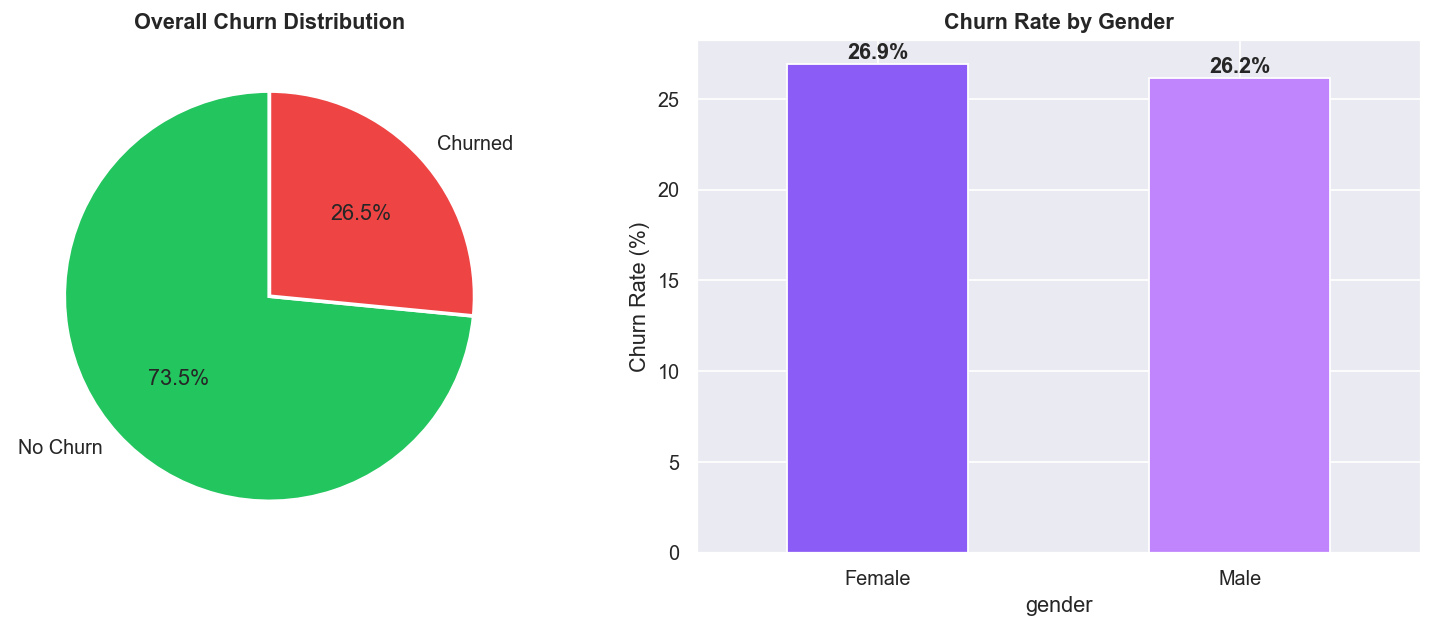

KEY FINDING: Churn rate = 26.5 %


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Pie chart
counts = df['Churn'].value_counts()
axes[0].pie(counts, labels=['No Churn','Churned'],
            autopct='%1.1f%%', colors=['#22c55e','#ef4444'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall Churn Distribution', fontweight='bold')
 
# Churn by gender
gender_churn = df.groupby('gender')['Churn'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[1],
                  color=['#8B5CF6','#c084fc'], rot=0)
axes[1].set_title('Churn Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
 
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/visuals/churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('KEY FINDING: Churn rate =', round(df['Churn'].mean()*100, 1), '%')

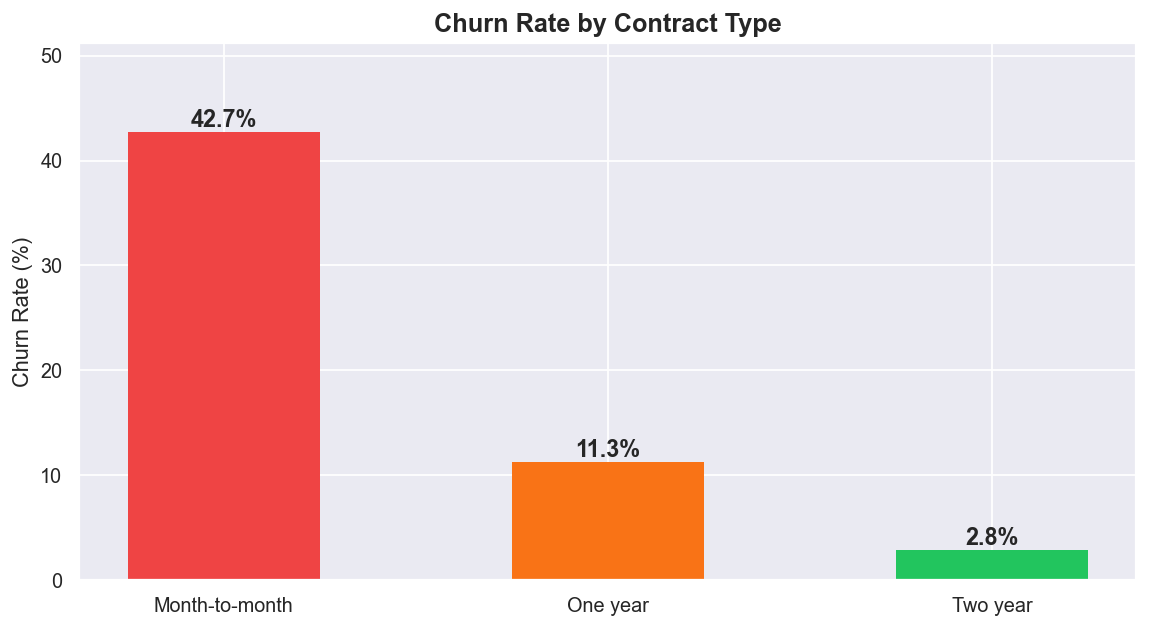

KEY FINDINGS - Churn by Contract:
  Month-to-month : 42.7 %
  One year : 11.3 %
  Two year : 2.8 %


In [51]:
contract_churn = (df.groupby('Contract')['Churn']
                  .mean().sort_values(ascending=False) * 100)
 
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#ef4444','#f97316','#22c55e'],
              edgecolor='none', width=0.5)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, contract_churn.max() * 1.2)
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/visuals/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('KEY FINDINGS - Churn by Contract:')
for contract, rate in contract_churn.items():
    print(' ', contract, ':', round(rate,1), '%')

C:\Users\BHANUPRAKASH\AppData\Local\Temp\ipykernel_14300\329738870.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Churn','Churned'])


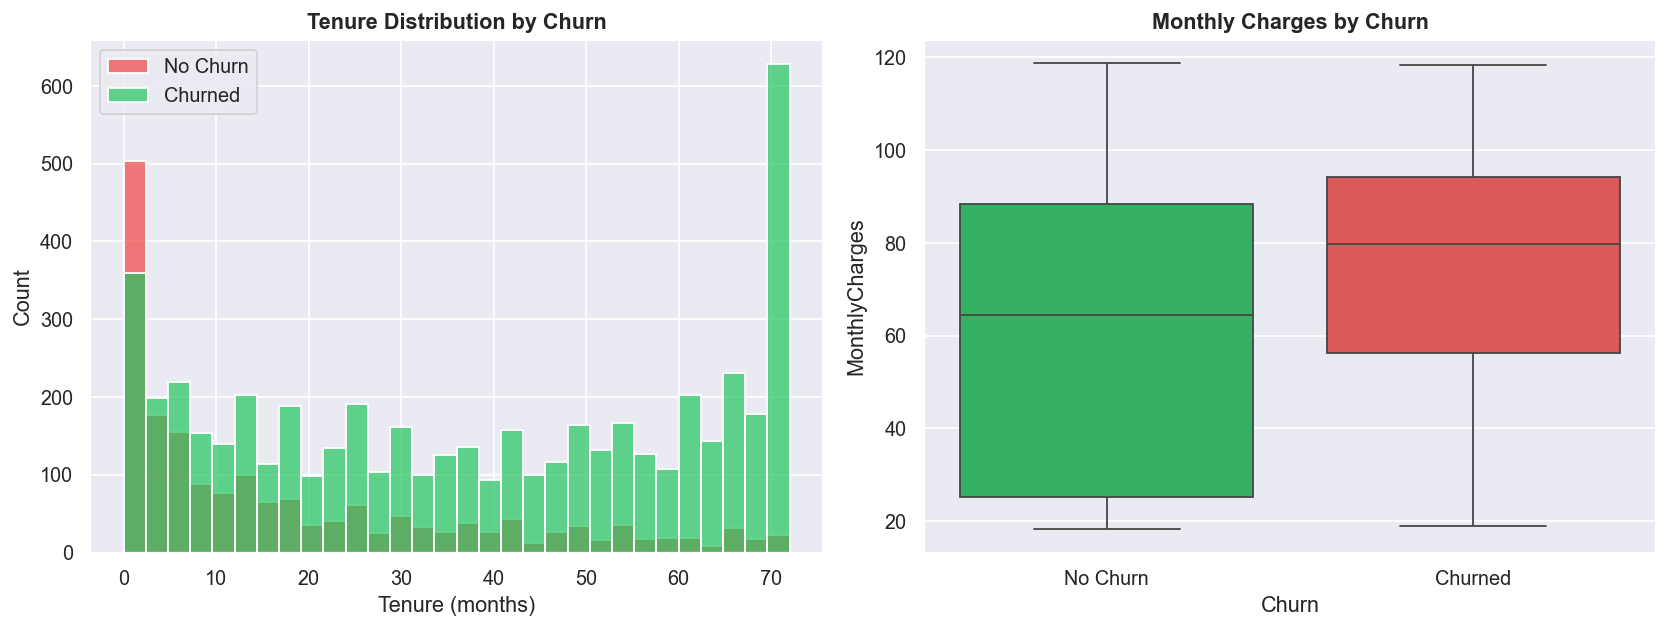

KEY FINDING: Avg tenure  — churned  = 18.0 months
KEY FINDING: Avg tenure  — retained = 37.6 months
KEY FINDING: Avg charges — churned  = $74.44
KEY FINDING: Avg charges — retained = $61.27


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             ax=axes[0], palette={0:'#22c55e',1:'#ef4444'}, alpha=0.7)
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend(['No Churn','Churned'])
 
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', 
            ax=axes[1], palette={0:'#22c55e',1:'#ef4444'}, legend= False)
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].set_xticklabels(['No Churn','Churned'])
 
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/visuals/tenure_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()
 
ch_tenure = df[df['Churn']==1]['tenure'].mean()
re_tenure = df[df['Churn']==0]['tenure'].mean()
ch_charge = df[df['Churn']==1]['MonthlyCharges'].mean()
re_charge = df[df['Churn']==0]['MonthlyCharges'].mean()
print('KEY FINDING: Avg tenure  — churned  =', round(ch_tenure,1), 'months')
print('KEY FINDING: Avg tenure  — retained =', round(re_tenure,1), 'months')
print('KEY FINDING: Avg charges — churned  = $' + f'{ch_charge:.2f}')
print('KEY FINDING: Avg charges — retained = $' + f'{re_charge:.2f}')

In [53]:
df_enc = pd.get_dummies(df,
    columns=['InternetService','Contract','PaymentMethod'],
    drop_first=False)
 
X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']
 
scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges']
X[num_cols] = scaler.fit_transform(X[num_cols])
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
print('Training set:', X_train.shape)
print('Test set    :', X_test.shape)
print('Churn rate in train:', round(y_train.mean()*100,1), '%')

Training set: (5634, 26)
Test set    : (1409, 26)
Churn rate in train: 26.5 %


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Example: separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessor: one-hot encode categorical, pass numeric unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# Build pipeline
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
     Churned       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

ROC-AUC: 0.862


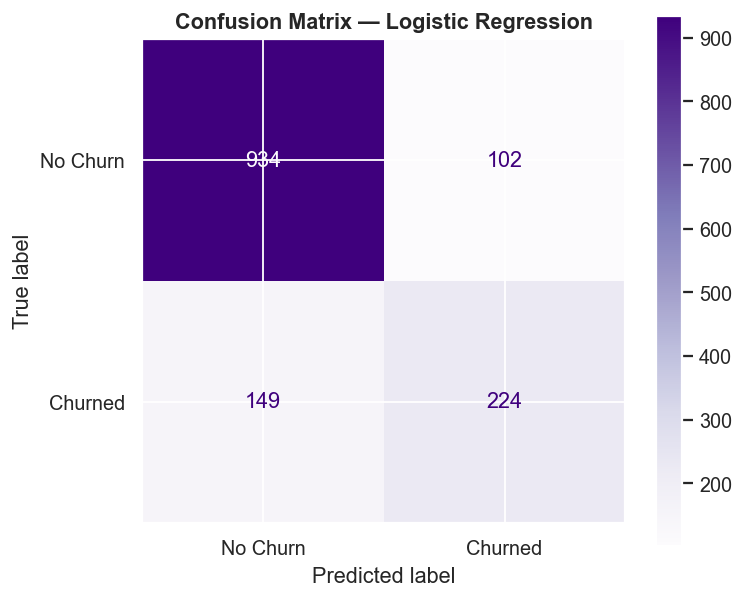

In [55]:
print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, lr_pred,
      target_names=['No Churn','Churned']))
print('ROC-AUC:', round(roc_auc_score(y_test, lr_prob), 3))
 
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['No Churn','Churned'],
    cmap='Purples', ax=ax)
ax.set_title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/visuals/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessor: one-hot encode categorical, scale numeric
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Build pipeline with preprocessing + model
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

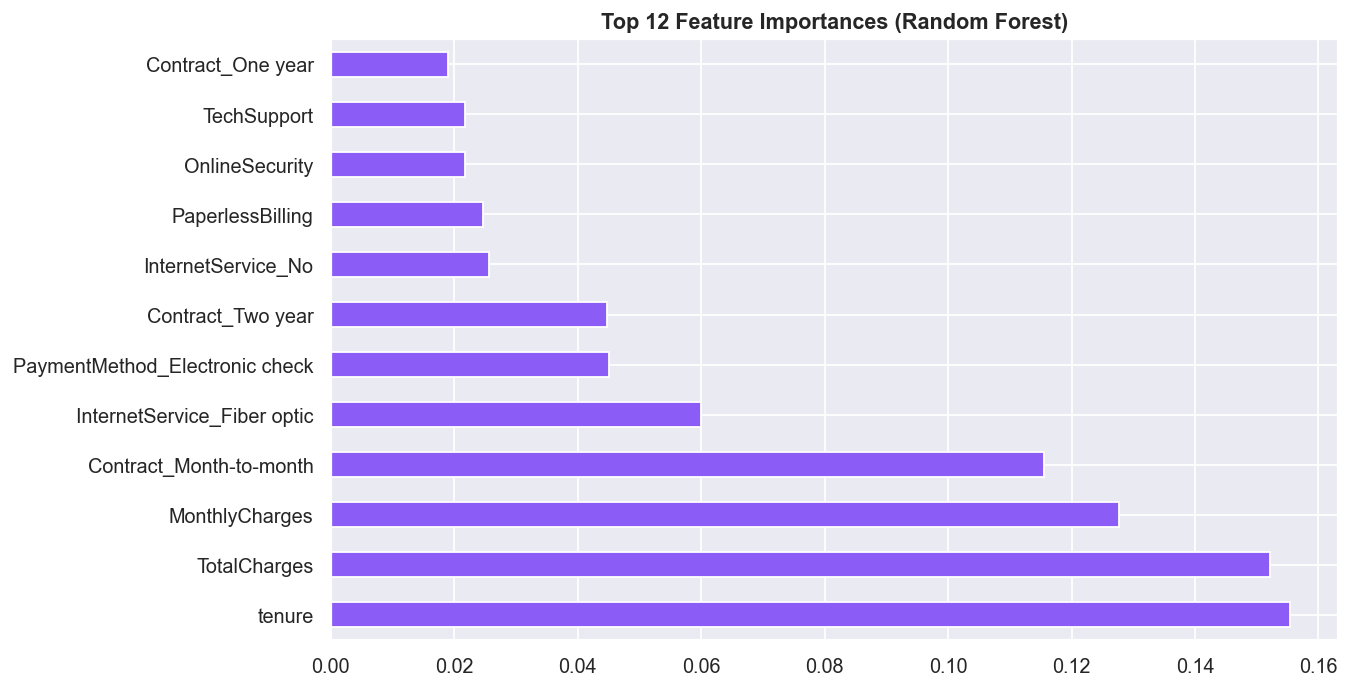

In [63]:
# Access the RandomForest model inside the pipeline
rf_model = rf.named_steps['classifier']

# Get feature names after preprocessing
cat_features = rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
num_features = numeric_cols
all_features = list(cat_features) + list(num_features)

# Feature importances
fi = (pd.Series(rf_model.feature_importances_, index=all_features)
        .sort_values(ascending=False)
        .head(12))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='barh', ax=ax, color='#8B5CF6')
ax.set_title('Top 12 Feature Importances (Random Forest)', fontweight='bold')
plt.show()


In [64]:
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/visuals/Top_12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 832x624 with 0 Axes>

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    No Churn       0.84      0.92      0.88      1036
     Churned       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.863


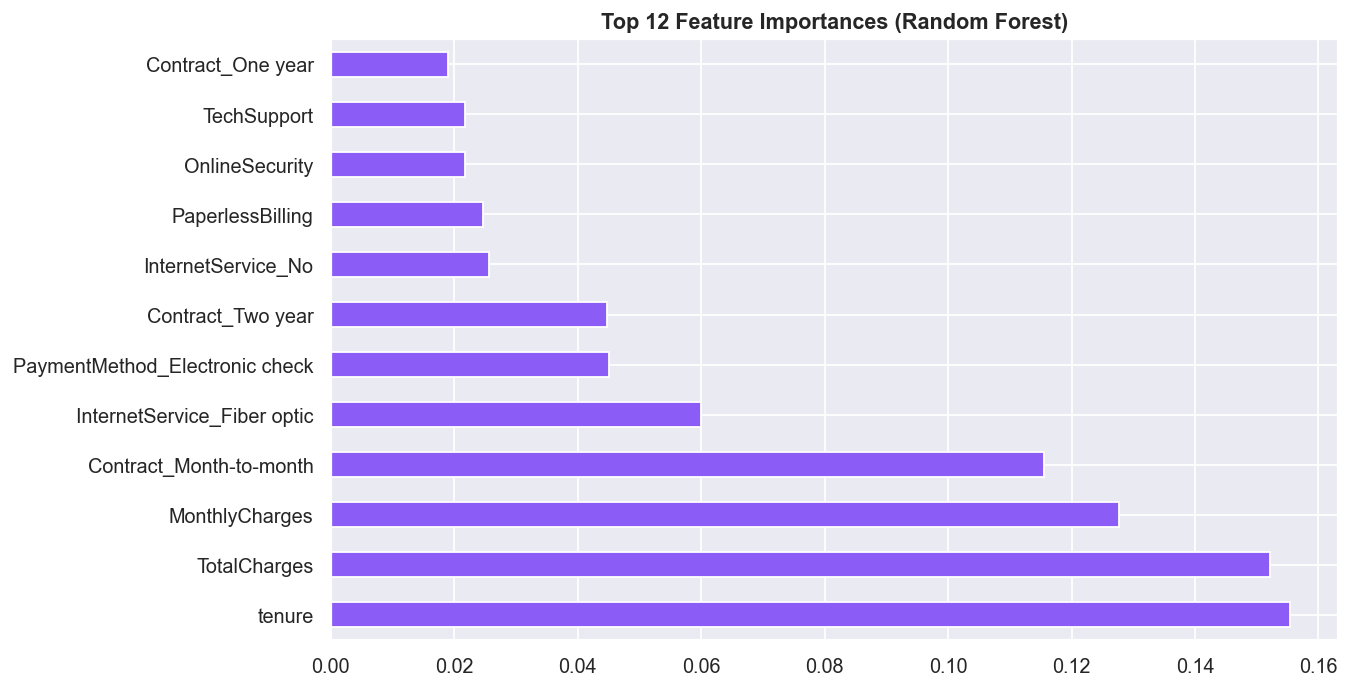

KEY FINDING: Top 3 churn predictors:
  tenure : 0.1554
  TotalCharges : 0.1522
  MonthlyCharges : 0.1277


<Figure size 832x624 with 0 Axes>

In [73]:
print('=== RANDOM FOREST ===')
print(classification_report(y_test, rf_pred,
      target_names=['No Churn','Churned']))
print('ROC-AUC:', round(roc_auc_score(y_test, rf_prob), 3))

# Access the RandomForest model inside the pipeline
rf_model = rf.named_steps['classifier']

#Get feature names after preprocessing
cat_features = rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
num_features = numeric_cols
all_features = list(cat_features) + list(num_features)
 # Feature importances
fi = (pd.Series(rf_model.feature_importances_, index=all_features)
        .sort_values(ascending=False)
        .head(12))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='barh', ax=ax, color='#8B5CF6')
ax.set_title('Top 12 Feature Importances (Random Forest)', fontweight='bold')
plt.show()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/visuals/feature_importance.png', dpi=150, bbox_inches='tight')
 
print('KEY FINDING: Top 3 churn predictors:')
for feat, score in fi.head(3).items():
    print(' ', feat, ':', round(score, 4))

In [71]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

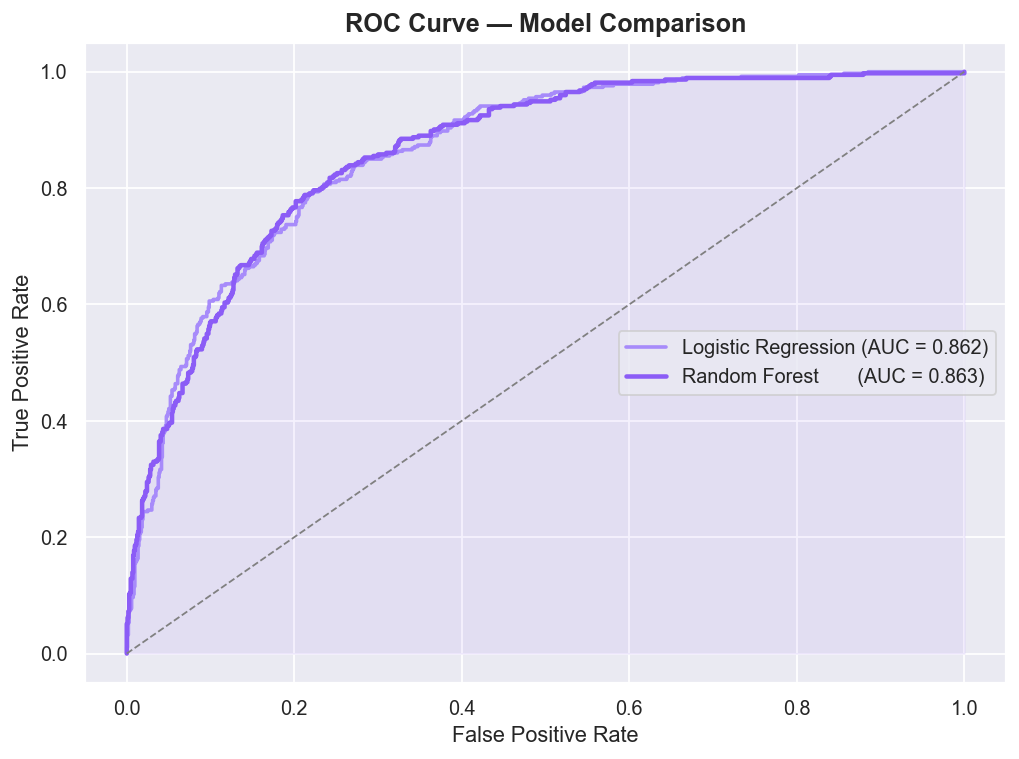

KEY FINDING: LR AUC  = 0.862
KEY FINDING: RF AUC  = 0.863
KEY FINDING: Best model = Random Forest


In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lr_fpr, lr_tpr, color='#a78bfa', linewidth=2,
        label='Logistic Regression (AUC = '+f'{lr_auc:.3f}'+')')
ax.plot(rf_fpr, rf_tpr, color='#8B5CF6', linewidth=2.5,
        label='Random Forest       (AUC = '+f'{rf_auc:.3f}'+')')
ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.fill_between(rf_fpr, rf_tpr, alpha=0.08, color='#8B5CF6')
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Customer Churn Analysis/visuals/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
 
best = 'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'
print('KEY FINDING: LR AUC  =', round(lr_auc, 3))
print('KEY FINDING: RF AUC  =', round(rf_auc, 3))
print('KEY FINDING: Best model =', best)

# Key Findings — Customer Churn Analysis
## Model Performance (fill from Cell 9 and 10 output)
| Model               | Accuracy | AUC   |
|---------------------|----------|-------|
| Logistic Regression | [0.82]   | [0.862]|
| Random Forest       | [0.81]   | [0.863]|
 
## Key Churn Drivers (fill from Cell 10 output)
1. [Tenure] — importance score: [0.1554]
2. [Total Charges] — importance score: [0.1522]
3. [Monthly Charges] — importance score: [0.1277]
 
## Business Recommendations
1. Target month-to-month customers with annual contract offers
2. Create onboarding program for customers in first 6 months
3. Review fiber optic pricing vs competitor rates